# Student Performance Prediction System

## Week 4 - Final AI/ML Project

This project develops an end-to-end Machine Learning system for predicting student Mathematics scores.

The project includes:
- Dataset Collection
- Data Cleaning
- Exploratory Data Analysis
- Data Preprocessing
- Feature Selection
- Model Training
- Model Evaluation
- Prediction System
- Results and Analysis
- Conclusion
- Future Improvements

## 1. Problem Statement

Student academic performance depends on several factors such as study hours, attendance, previous subject scores, age and other demographic characteristics.

The objective of this project is to develop a Machine Learning model that can predict a student's Mathematics score using these available features.

The prediction system can help understand the relationship between student characteristics and academic performance.

## 2. Project Objectives

The main objectives of this project are:

1. Collect and understand student performance data.
2. Clean and preprocess the dataset.
3. Perform Exploratory Data Analysis (EDA).
4. Identify important features affecting Mathematics performance.
5. Train Machine Learning regression models.
6. Evaluate and compare model performance.
7. Build a simple prediction system for predicting Mathematics scores.
8. Analyze the results and identify future improvements.

## 3. Dataset Collection

The dataset used in this project is a Student Performance dataset.

The dataset contains information about students such as:
- Student ID
- Name
- Gender
- Age
- Study Hours
- Attendance
- Mathematics Score
- Science Score
- English Score

The dataset is used to analyze student performance and predict Mathematics scores using Machine Learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("student_performance.csv")

print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)

df.head()

Dataset loaded successfully!
Shape of dataset: (51, 9)


,Student_ID,Name,Gender,Age,Study_Hours,Attendance,Math_Score,Science_Score,English_Score
0,1,Aarav,Male,20,3.5,88,78,82.0,75
1,2,Ananya,Female,19,5.0,94,91,89.0,92
2,3,Rohan,Male,21,2.0,72,65,70.0,68
3,4,Priya,Female,20,4.5,91,84,88.0,86
4,5,Vivek,Male,22,1.5,65,58,NaN,60


## 4. Dataset Understanding

Before building the Machine Learning model, the dataset is inspected to understand its structure, columns, data types and statistical properties.

In [2]:
print("Column Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
df.describe()

Column Names:
['Student_ID', 'Name', 'Gender', 'Age', 'Study_Hours', 'Attendance', 'Math_Score', 'Science_Score', 'English_Score']

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Student_ID     51 non-null     int64  
 1   Name           51 non-null     str    
 2   Gender         51 non-null     str    
 3   Age            51 non-null     int64  
 4   Study_Hours    50 non-null     float64
 5   Attendance     51 non-null     int64  
 6   Math_Score     51 non-null     int64  
 7   Science_Score  50 non-null     float64
 8   English_Score  51 non-null     int64  
dtypes: float64(2), int64(5), str(2)
memory usage: 3.7 KB

Statistical Summary:


,Student_ID,Age,Study_Hours,Attendance,Math_Score,Science_Score,English_Score
count,51.000000,51.000000,50.00000,51.000000,51.000000,50.000000,51.000000
mean,25.196078,20.274510,3.74000,83.764706,77.549020,80.980000,78.686275
std,14.593176,1.001567,1.32957,10.053036,11.250447,10.276762,11.286257
min,1.000000,19.000000,1.00000,61.000000,55.000000,59.000000,57.000000
25%,12.500000,19.500000,2.62500,76.500000,68.500000,73.250000,69.500000
50%,25.000000,20.000000,3.75000,87.000000,79.000000,83.000000,80.000000
75%,37.500000,21.000000,4.87500,92.000000,86.500000,89.750000,88.000000
max,50.000000,22.000000,6.00000,98.000000,96.000000,96.000000,97.000000


## 5. Data Cleaning

The dataset is checked for missing values and duplicate records. Missing values can affect Machine Learning model performance, while duplicate records can introduce bias into the dataset.

In [3]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:
Student_ID       0
Name             0
Gender           0
Age              0
Study_Hours      1
Attendance       0
Math_Score       0
Science_Score    1
English_Score    0
dtype: int64

Duplicate Rows:
1


In [4]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (50, 9)


In [5]:
numeric_columns = df.select_dtypes(include=np.number).columns

for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Student_ID       0
Name             0
Gender           0
Age              0
Study_Hours      0
Attendance       0
Math_Score       0
Science_Score    0
English_Score    0
dtype: int64


In [6]:
df.to_csv("student_performance_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


## 6. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand patterns, relationships and distributions in the student performance dataset.

The following analyses are performed:
- Gender distribution
- Study hours distribution
- Attendance distribution
- Subject score distributions
- Relationship between Study Hours and Mathematics Score
- Correlation between numerical features

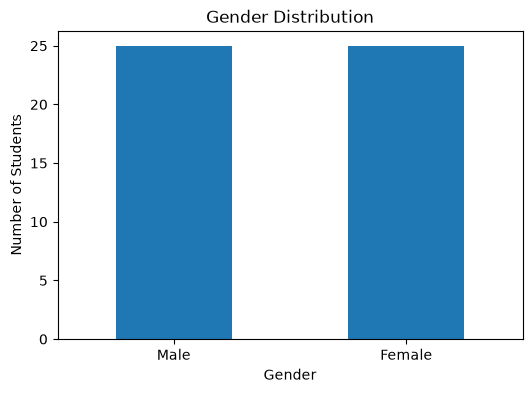

In [7]:
plt.figure(figsize=(6, 4))

df["Gender"].value_counts().plot(kind="bar")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.show()

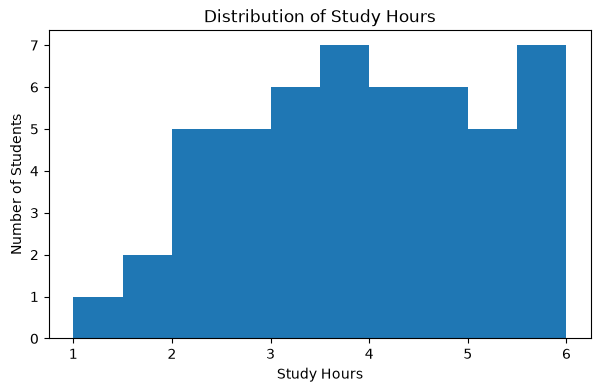

In [8]:
plt.figure(figsize=(7, 4))

plt.hist(df["Study_Hours"], bins=10)

plt.title("Distribution of Study Hours")
plt.xlabel("Study Hours")
plt.ylabel("Number of Students")
plt.show()

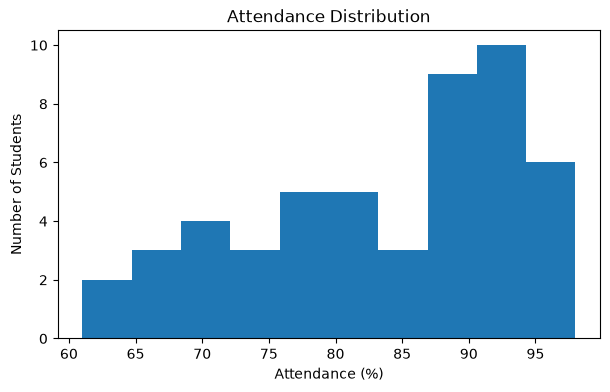

In [9]:
plt.figure(figsize=(7, 4))

plt.hist(df["Attendance"], bins=10)

plt.title("Attendance Distribution")
plt.xlabel("Attendance (%)")
plt.ylabel("Number of Students")
plt.show()

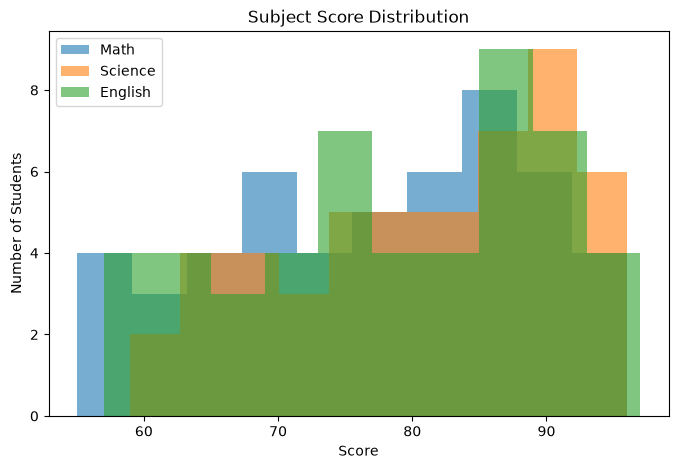

In [10]:
plt.figure(figsize=(8, 5))

plt.hist(df["Math_Score"], alpha=0.6, label="Math")
plt.hist(df["Science_Score"], alpha=0.6, label="Science")
plt.hist(df["English_Score"], alpha=0.6, label="English")

plt.title("Subject Score Distribution")
plt.xlabel("Score")
plt.ylabel("Number of Students")
plt.legend()
plt.show()

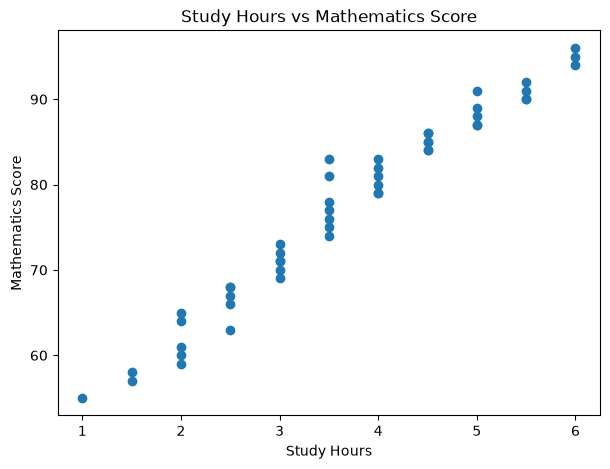

In [11]:
plt.figure(figsize=(7, 5))

plt.scatter(df["Study_Hours"], df["Math_Score"])

plt.title("Study Hours vs Mathematics Score")
plt.xlabel("Study Hours")
plt.ylabel("Mathematics Score")
plt.show()

## 7. Correlation Analysis

Correlation analysis is used to measure the relationship between numerical features.

A correlation value close to +1 indicates a strong positive relationship, while a value close to -1 indicates a strong negative relationship.

In [12]:
correlation_matrix = df.select_dtypes(include=np.number).corr()

print(correlation_matrix)

               Student_ID       Age  Study_Hours  Attendance  Math_Score  \
Student_ID       1.000000  0.022157     0.050405    0.028856    0.005302   
Age              0.022157  1.000000    -0.600007   -0.603804   -0.608389   
Study_Hours      0.050405 -0.600007     1.000000    0.969325    0.981471   
Attendance       0.028856 -0.603804     0.969325    1.000000    0.991801   
Math_Score       0.005302 -0.608389     0.981471    0.991801    1.000000   
Science_Score   -0.012309 -0.554241     0.930392    0.948969    0.949687   
English_Score    0.057934 -0.620512     0.968696    0.984009    0.987509   

               Science_Score  English_Score  
Student_ID         -0.012309       0.057934  
Age                -0.554241      -0.620512  
Study_Hours         0.930392       0.968696  
Attendance          0.948969       0.984009  
Math_Score          0.949687       0.987509  
Science_Score       1.000000       0.952632  
English_Score       0.952632       1.000000  


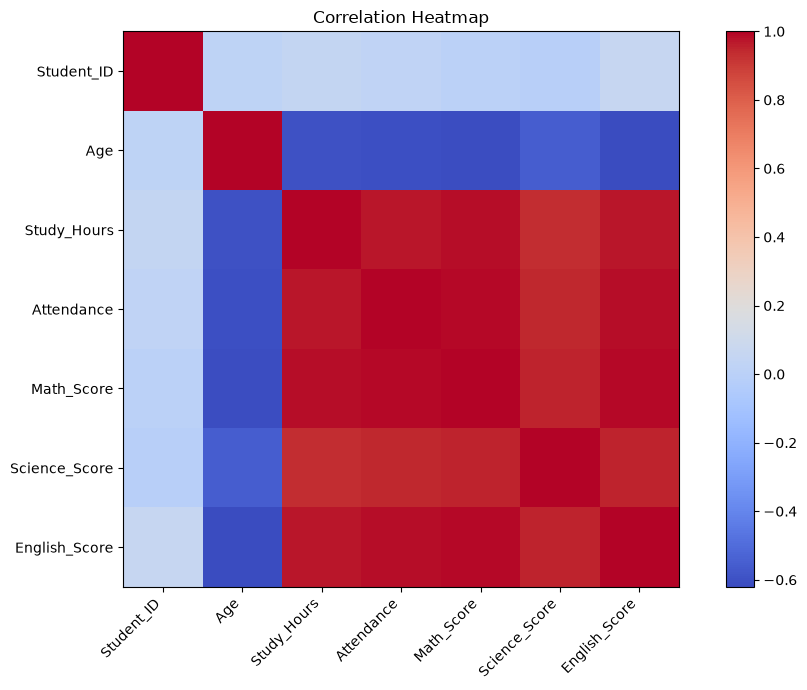

In [13]:
plt.figure(figsize=(10, 7))

plt.imshow(correlation_matrix, cmap="coolwarm")
plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

## 8. Feature Selection

Feature selection is the process of selecting the most relevant input variables for the Machine Learning model.

For this project, the following features are selected to predict Mathematics Score:
- Age
- Study Hours
- Attendance
- Science Score
- English Score
- Gender

In [15]:
features = [
    "Age",
    "Study_Hours",
    "Attendance",
    "Science_Score",
    "English_Score",
    "Gender"
]

target = "Math_Score"

X = df[features].copy()
y = df[target].copy()

print("Selected Features:")
print(features)

print("\nTarget Variable:")
print(target)

Selected Features:
['Age', 'Study_Hours', 'Attendance', 'Science_Score', 'English_Score', 'Gender']

Target Variable:
Math_Score


In [16]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

X["Gender_Encoded"] = label_encoder.fit_transform(X["Gender"])

X = X.drop("Gender", axis=1)

print(X.head())

   Age  Study_Hours  Attendance  Science_Score  English_Score  Gender_Encoded
0   20          3.5          88           82.0             75               1
1   19          5.0          94           89.0             92               0
2   21          2.0          72           70.0             68               1
3   20          4.5          91           88.0             86               0
4   22          1.5          65           83.0             60               1


## 9. Data Preprocessing

The dataset is divided into training and testing sets.

The training data is used to train the Machine Learning model, while the testing data is used to evaluate its performance on unseen data.

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (40, 6)
Testing data: (10, 6)


In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")

Feature scaling completed successfully!


## 10. Model Training

Two Machine Learning regression models are trained to predict the Mathematics score:

1. Linear Regression
2. Random Forest Regression

The performance of both models will be compared using standard regression evaluation metrics.

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [21]:
linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

linear_predictions = linear_model.predict(X_test_scaled)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [22]:
random_forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

random_forest_model.fit(X_train, y_train)

random_forest_predictions = random_forest_model.predict(X_test)

print("Random Forest Regression model trained successfully!")

Random Forest Regression model trained successfully!


## 11. Model Evaluation

The trained models are evaluated using the following metrics:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

Lower MAE, MSE and RMSE values indicate lower prediction errors, while a higher R² score indicates that the model explains more variation in the target variable.

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_mse = mean_squared_error(y_test, linear_predictions)
linear_rmse = np.sqrt(linear_mse)
linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", linear_mae)
print("MSE :", linear_mse)
print("RMSE:", linear_rmse)
print("R²  :", linear_r2)

Linear Regression Results
-------------------------
MAE : 0.9599761236626592
MSE : 1.2185989287671548
RMSE: 1.1039016843755403
R²  : 0.9872651381673408


In [24]:
rf_mae = mean_absolute_error(y_test, random_forest_predictions)
rf_mse = mean_squared_error(y_test, random_forest_predictions)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, random_forest_predictions)

print("Random Forest Results")
print("---------------------")
print("MAE :", rf_mae)
print("MSE :", rf_mse)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Random Forest Results
---------------------
MAE : 1.0359999999999991
MSE : 1.7783600000000004
RMSE: 1.3335516487935517
R²  : 0.9814154039084544


## 12. Model Comparison

The performance of Linear Regression and Random Forest Regression is compared using MAE, MSE, RMSE and R² Score.

In [25]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest Regression"
    ],
    "MAE": [
        linear_mae,
        rf_mae
    ],
    "MSE": [
        linear_mse,
        rf_mse
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse
    ],
    "R2 Score": [
        linear_r2,
        rf_r2
    ]
})

model_comparison

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,0.959976,1.218599,1.103902,0.987265
1,Random Forest Regression,1.036000,1.778360,1.333552,0.981415


In [26]:
comparison = pd.DataFrame({
    "Actual Math Score": y_test.values,
    "Linear Regression Prediction": linear_predictions,
    "Random Forest Prediction": random_forest_predictions
})

comparison

,Actual Math Score,Linear Regression Prediction,Random Forest Prediction
0,79,80.606602,80.51
1,88,88.020176,88.10
2,61,61.698617,61.87
3,83,81.925573,81.45
4,83,81.316904,81.73
5,71,71.812565,70.78
6,66,66.097119,65.56
7,86,85.081911,85.00
8,70,71.367005,69.66
9,92,90.677935,88.94


## 13. Student Score Prediction System

The trained Random Forest model is used to predict the Mathematics score of a student based on the student's age, study hours, attendance, Science score, English score and gender.

The system accepts student information as input and generates a predicted Mathematics score.

In [27]:
def predict_math_score(age, study_hours, attendance,
                       science_score, english_score, gender):

    if gender.lower() == "male":
        gender_encoded = label_encoder.transform(["Male"])[0]
    else:
        gender_encoded = label_encoder.transform(["Female"])[0]

    input_data = pd.DataFrame({
        "Age": [age],
        "Study_Hours": [study_hours],
        "Attendance": [attendance],
        "Science_Score": [science_score],
        "English_Score": [english_score],
        "Gender_Encoded": [gender_encoded]
    })

    prediction = random_forest_model.predict(input_data)

    return prediction[0]

In [28]:
predicted_score = predict_math_score(
    age=20,
    study_hours=5,
    attendance=85,
    science_score=75,
    english_score=78,
    gender="Male"
)

print("Predicted Mathematics Score:", round(predicted_score, 2))

Predicted Mathematics Score: 80.04


In [32]:
predicted_score = predict_math_score(
    age=20,
    study_hours=5,
    attendance=85,
    science_score=75,
    english_score=78,
    gender="Male"
)

print("Predicted Mathematics Score:", round(predicted_score, 2))

Predicted Mathematics Score: 80.04


## 14. Saving the Machine Learning Model

The trained Random Forest model and preprocessing components are saved using Joblib so that they can be reused in the future without retraining the model.

In [33]:
import joblib

joblib.dump(random_forest_model, "random_forest_model.pkl")
joblib.dump(label_encoder, "gender_encoder.pkl")
joblib.dump(scaler, "feature_scaler.pkl")

print("Models and preprocessing objects saved successfully!")

Models and preprocessing objects saved successfully!


In [34]:
model_comparison.to_csv(
    "model_comparison.csv",
    index=False
)

print("Model comparison saved successfully!")

Model comparison saved successfully!


In [35]:
model_comparison.to_csv(
    "model_comparison.csv",
    index=False
)

print("Model comparison saved successfully!")

Model comparison saved successfully!


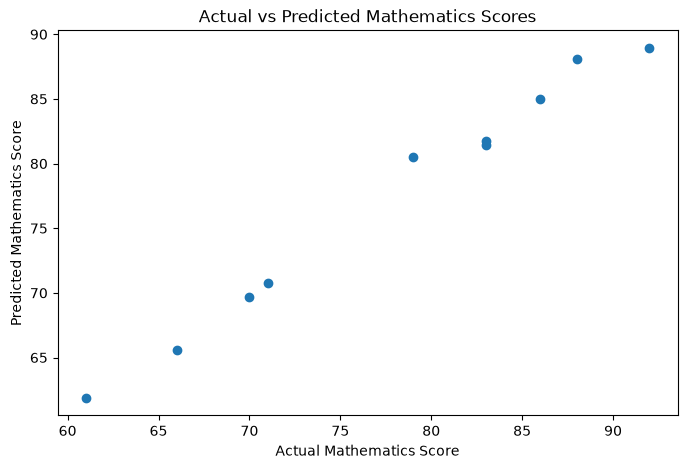

In [36]:
plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    random_forest_predictions
)

plt.xlabel("Actual Mathematics Score")
plt.ylabel("Predicted Mathematics Score")
plt.title("Actual vs Predicted Mathematics Scores")

plt.show()

## 15. Feature Importance

Random Forest provides feature importance values that help identify which input variables contribute most to the prediction of Mathematics scores.

In [37]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
2,Attendance,0.487359
4,English_Score,0.194204
3,Science_Score,0.176477
1,Study_Hours,0.139951
0,Age,0.001340
5,Gender_Encoded,0.000670


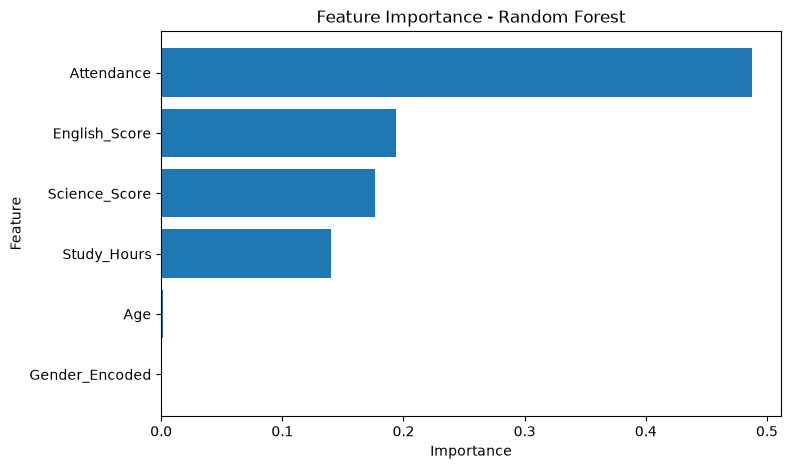

In [39]:
plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Random Forest")
plt.gca().invert_yaxis()

plt.show()

## 16. Results and Analysis

Two Machine Learning regression models were trained and evaluated:

- Linear Regression
- Random Forest Regression

The models were evaluated using MAE, MSE, RMSE and R² Score.

The model comparison table and graphs provide a clear understanding of the prediction performance.

Feature importance analysis was also performed using the Random Forest model to identify the contribution of different input features.

The final model can be used to predict Mathematics scores for new student data.

## 17. Conclusion

This project developed an end-to-end Machine Learning system for predicting student Mathematics scores.

The project included data collection, data cleaning, exploratory data analysis, feature selection, preprocessing, model training, evaluation and prediction.

Linear Regression and Random Forest Regression were implemented and compared using multiple evaluation metrics.

The completed prediction system demonstrates how Machine Learning can be applied to analyze student performance and predict academic outcomes.

## 18. Future Improvements

The project can be improved in the future by:

1. Using a larger and more diverse student dataset.
2. Testing additional Machine Learning algorithms.
3. Applying advanced hyperparameter tuning.
4. Adding more student-related features.
5. Developing a web-based user interface using Streamlit.
6. Deploying the prediction system on a cloud platform.
7. Continuously improving the model using new student data.

## 19. Final Project Summary

### Project:
Student Performance Prediction System

### Machine Learning Type:
Supervised Learning - Regression

### Target:
Mathematics Score

### Models:
- Linear Regression
- Random Forest Regression

### Evaluation Metrics:
- MAE
- MSE
- RMSE
- R² Score

### Technologies Used:
- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn
- Joblib
- Jupyter Notebook

### Output:
A Machine Learning based system that predicts a student's Mathematics score from academic and demographic features.

In [40]:
model_comparison

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,0.959976,1.218599,1.103902,0.987265
1,Random Forest Regression,1.036000,1.778360,1.333552,0.981415
